# Ingestion baseline: scalability and bottlenecks

This notebook analyzes the reproducible reports generated by `scripts/run_ingestion_baseline.py`. Its purpose is to identify how execution time, throughput, and peak memory change as the input grows while the chunk size remains fixed.

## Experimental protocol

- One warm-up followed by three measured runs per scale.
- A fresh isolated PostgreSQL volume before every run.
- Alembic migrations applied before every ingestion.
- Fixed chunk size of 100,000 source rows.
- Warm-ups excluded from all reported statistics.
- Raw reports kept outside Git; only the privacy-safe aggregate is versioned.

The experiment measures the current implementation. Its global deduplication sets, independent table transactions, and lack of idempotency are intentionally preserved as baseline limitations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from analysis.ingestion_baseline import (
    aggregate_runs,
    load_experiment,
    measured_runs,
    stage_medians,
    write_public_summary,
)

pd.set_option("display.max_columns", None)
MANIFEST_PATH = Path("/app/artifacts/ingestion/manifest.json")
SUMMARY_PATH = Path("/app/results/ingestion-baseline-summary.csv")

runs, chunks, metadata = load_experiment(MANIFEST_PATH)
measured = measured_runs(runs)
summary = aggregate_runs(runs)
metadata

{'schema_version': 1,
 'chunk_size': 100000,
 'warmups': 1,
 'repetitions': 3,
 'sizes': [100000, 1000000]}

## Validation

The loader rejects incomplete manifests, incompatible schemas, path traversal, mismatched chunk sizes, and partial row counts. The checks below also ensure that every scale has the planned number of measured repetitions and deterministic entity counts.

In [2]:
runs_per_scale = measured.groupby("source_rows")["run"].count()
assert runs_per_scale.eq(metadata["repetitions"]).all()

entity_columns = [
    "responsavel_inserted",
    "beneficiario_inserted",
    "auxilio_inserted",
]
assert measured.groupby("source_rows")[entity_columns].nunique().eq(1).all().all()

measured[["source_rows", "run", *entity_columns]].sort_values(
    ["source_rows", "run"]
)

,source_rows,run,responsavel_inserted,beneficiario_inserted,auxilio_inserted
1,100000,1,37237,76799,76799
2,100000,2,37237,76799,76799
3,100000,3,37237,76799,76799
5,1000000,1,364595,698314,698314
6,1000000,2,364595,698314,698314
7,1000000,3,364595,698314,698314


## Aggregate results

The median is the primary estimator because only three measured repetitions are available and isolated slow runs can distort the mean. The coefficient of variation quantifies relative dispersion.

In [3]:
summary_columns = [
    "source_rows",
    "repetitions",
    "wall_clock_seconds_median",
    "wall_clock_seconds_cv_percent",
    "source_rows_per_second_median",
    "source_rows_per_second_cv_percent",
    "peak_memory_mb_median",
    "peak_memory_mb_cv_percent",
]
summary[summary_columns].round(3)

,source_rows,repetitions,wall_clock_seconds_median,wall_clock_seconds_cv_percent,source_rows_per_second_median,source_rows_per_second_cv_percent,peak_memory_mb_median,peak_memory_mb_cv_percent
0,100000,3,4.800,3.619,20831.788,3.549,214.246,0.299
1,1000000,3,49.654,5.398,20139.310,5.569,387.910,1.520


## Time decomposition

Each stacked bar shows the median elapsed time across the three measured runs, separated into setup, CSV reading, Pandas transformation, and PostgreSQL writing. PostgreSQL writes dominate both scales. Transformation consumes a larger share at one million rows, which is compatible with increasing cross-chunk deduplication work, but this baseline does not isolate causality.

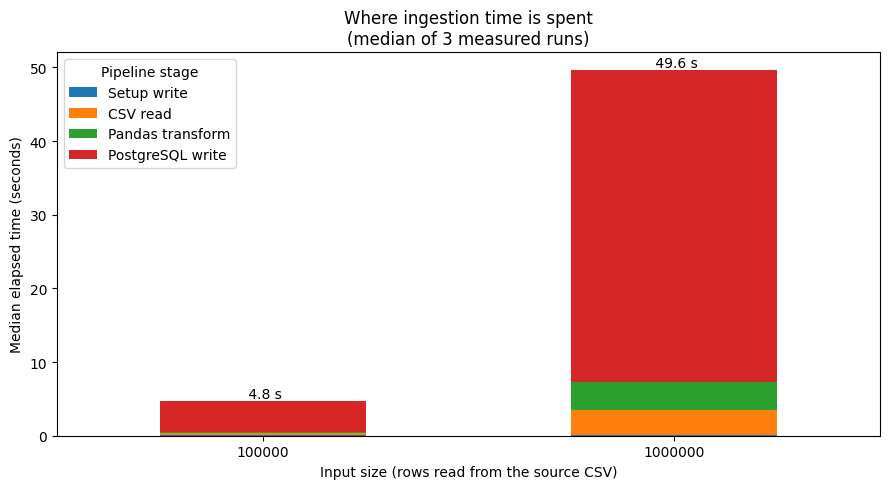

In [4]:
stages = stage_medians(runs).rename(
    columns={
        "setup_write_seconds": "Setup write",
        "read_seconds": "CSV read",
        "transform_seconds": "Pandas transform",
        "write_seconds": "PostgreSQL write",
    }
)
ax = stages.plot(kind="bar", stacked=True, figsize=(9, 5))
ax.set_title("Where ingestion time is spent\n(median of 3 measured runs)")
ax.set_xlabel("Input size (rows read from the source CSV)")
ax.set_ylabel("Median elapsed time (seconds)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Pipeline stage")
for position, total in enumerate(stages.sum(axis=1)):
    ax.text(position, total, f" {total:.1f} s", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Throughput and peak memory

The left chart reports source CSV rows processed per second, not the larger number of normalized records written across three tables. The right chart reports the median process-lifetime peak RSS. Throughput stays near 20 thousand source rows per second while the larger experiment reaches a higher memory peak; peak RSS alone does not prove that all of that memory remains live.

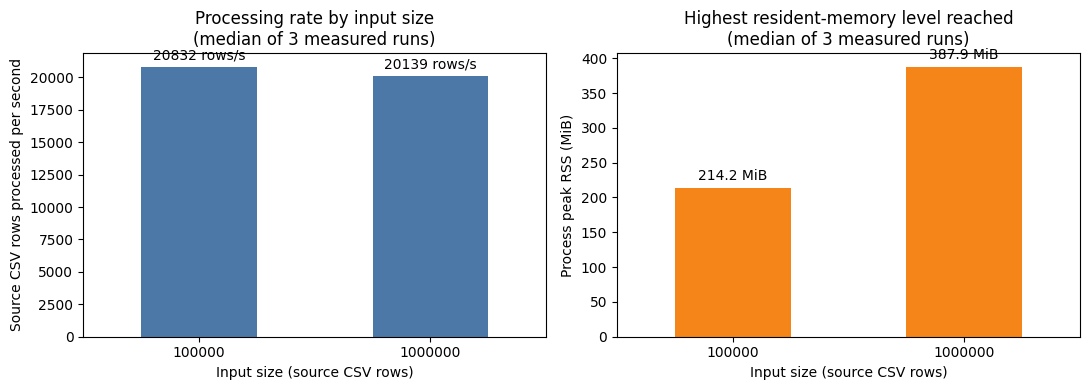

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_data = summary.set_index("source_rows")
plot_data["source_rows_per_second_median"].plot(
    kind="bar", ax=axes[0], color="#4C78A8"
)
axes[0].set_title("Processing rate by input size\n(median of 3 measured runs)")
axes[0].set_xlabel("Input size (source CSV rows)")
axes[0].set_ylabel("Source CSV rows processed per second")
axes[0].tick_params(axis="x", rotation=0)
axes[0].bar_label(axes[0].containers[0], fmt="%.0f rows/s", padding=3)

plot_data["peak_memory_mb_median"].plot(
    kind="bar", ax=axes[1], color="#F58518"
)
axes[1].set_title("Highest resident-memory level reached\n(median of 3 measured runs)")
axes[1].set_xlabel("Input size (source CSV rows)")
axes[1].set_ylabel("Process peak RSS (MiB)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].bar_label(axes[1].containers[0], fmt="%.1f MiB", padding=3)
plt.tight_layout()
plt.show()

## Memory growth across chunks

Each point is the median, across the three measured runs, of the highest RSS reached by that point in the ingestion. RSS means the portion of process memory resident in physical RAM; peak RSS is a historical high-water mark. Consequently, this curve cannot decrease even if Python later releases objects. It describes when new memory peaks occur, but current RSS and deduplication-set cardinalities are still needed to demonstrate retained state.

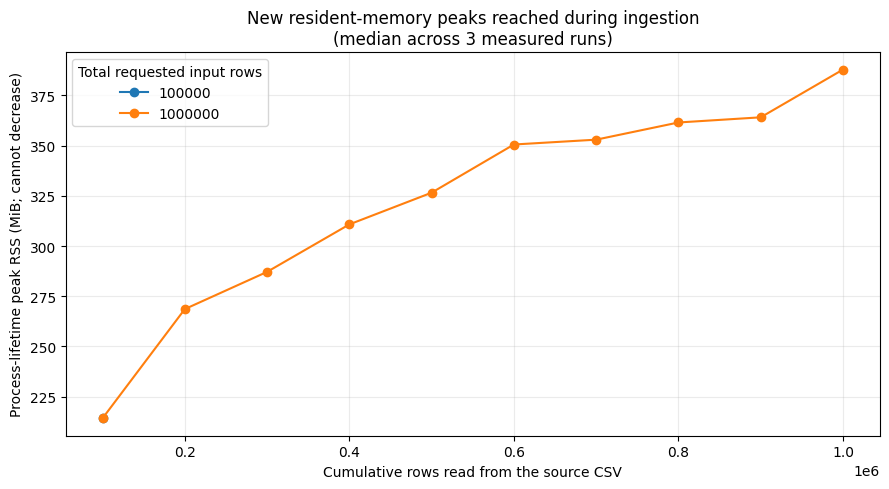

In [6]:
measured_chunks = chunks.loc[chunks["kind"] == "run"]
memory_growth = (
    measured_chunks.groupby(["source_rows", "processed_rows"])["peak_memory_mb"]
    .median()
    .unstack("source_rows")
)
ax = memory_growth.plot(marker="o", figsize=(9, 5))
ax.set_title("New resident-memory peaks reached during ingestion\n(median across 3 measured runs)")
ax.set_xlabel("Cumulative rows read from the source CSV")
ax.set_ylabel("Process-lifetime peak RSS (MiB; cannot decrease)")
ax.legend(title="Total requested input rows")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Versionable public summary

Only aggregate metrics are exported. Absolute dataset paths, usernames, raw rows, CPF, and NIS values are not included.

In [7]:
write_public_summary(summary, SUMMARY_PATH)
print(f"Summary written to {SUMMARY_PATH}")

Summary written to /app/results/ingestion-baseline-summary.csv


## Conclusions and limitations

- PostgreSQL writing is the dominant stage at both observed scales.
- Median throughput changes little between 100 thousand and one million source rows.
- The one-million-row experiment reaches a median peak RSS of roughly 388 MiB, versus 214 MiB at 100 thousand rows.
- Code inspection shows that cross-chunk deduplication sets are unbounded; the measured peaks quantify the baseline but do not independently prove retained live memory.
- Two scales and three measured repetitions are enough to expose a trend, but not to claim asymptotic behavior.
- Peak RSS is a process-lifetime high-water mark, not instantaneous memory usage.
- Host filesystem cache, Docker, PostgreSQL configuration, and background system activity remain threats to validity.
- The next experiment should add larger scales before comparing the current pipeline with a staging-based implementation.